In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv("CC GENERAL.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [9]:
# Remove ID column
data = df.drop("CUST_ID", axis=1).copy()

# Handle missing values
data["MINIMUM_PAYMENTS"] = data["MINIMUM_PAYMENTS"].fillna(
    data["MINIMUM_PAYMENTS"].median()
)

data["CREDIT_LIMIT"] = data["CREDIT_LIMIT"].fillna(
    data["CREDIT_LIMIT"].median()
)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(data)

print("Missing Values:", data.isnull().sum().sum())
print("Scaled Data Shape:", X.shape)

Missing Values: 0
Scaled Data Shape: (8950, 17)


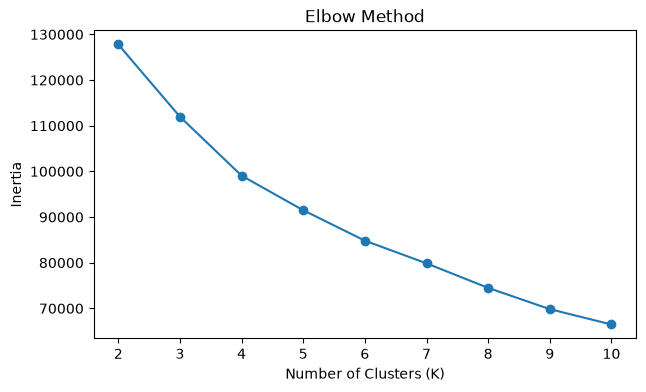

K = 2 | Silhouette Score = 0.2100
K = 3 | Silhouette Score = 0.2510
K = 4 | Silhouette Score = 0.1977
K = 5 | Silhouette Score = 0.1931
K = 6 | Silhouette Score = 0.2029
K = 7 | Silhouette Score = 0.2077
K = 8 | Silhouette Score = 0.2217
K = 9 | Silhouette Score = 0.2260
K = 10 | Silhouette Score = 0.2204


In [10]:
inertia = []
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Elbow Method
plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Score
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k} | Silhouette Score = {score:.4f}")

In [11]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

# Centroids in original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroid_df = pd.DataFrame(
    centroids,
    columns=data.columns
)

print("Cluster Count:")
print(df["Cluster"].value_counts().sort_index())

print("\nCentroid / Average Profile:")
display(centroid_df)

print("\nCluster-wise Average:")
display(df.groupby("Cluster")[data.columns].mean())

Cluster Count:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64

Centroid / Average Profile:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595



Cluster-wise Average:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.710597,974.260054,569.001764,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1985.036426,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2020.801857,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,646.019774,0.269258,11.594595


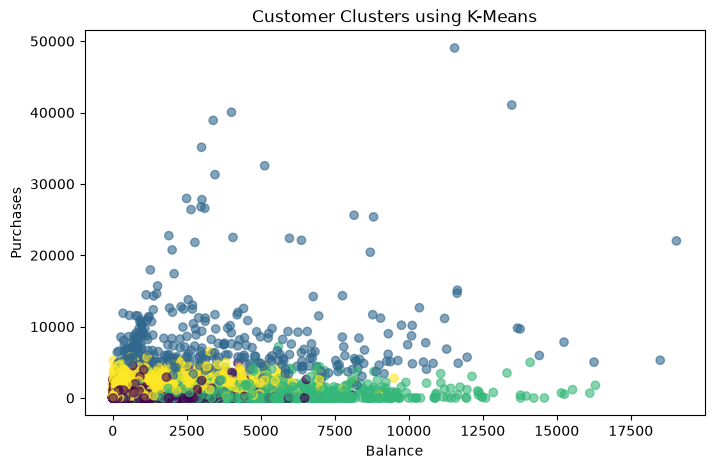

In [12]:
# Cell 5: Cluster Visualization

plt.figure(figsize=(8, 5))

plt.scatter(
    data["BALANCE"],
    data["PURCHASES"],
    c=df["Cluster"],
    alpha=0.6
)

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("Customer Clusters using K-Means")

plt.show()